In [137]:
# Neccessary imports
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, GridSearchCV

In [112]:
# Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
df = pd.read_csv(url)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [113]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [114]:
df.shape

(506, 14)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [116]:
# Check for null values
df.isnull().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [117]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [118]:
corr = df.corr(numeric_only=True)

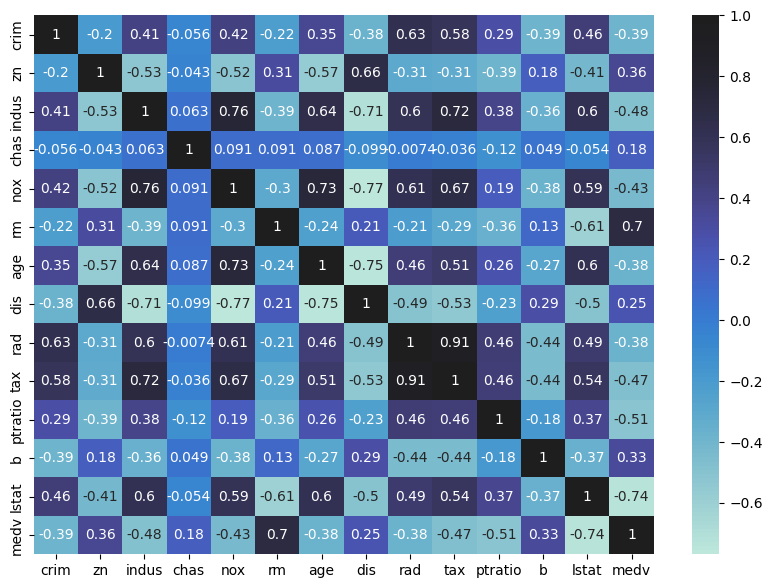

In [119]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, center=True)
plt.show()

In [120]:
df.columns= [
    'crime',
    'zone',
    'industry',
    'river',
    'air pollution',
    'rooms',
    'age',
    'distance',
    'highway access',
    'ptax',
    'ptration',
    'bindex',
    'lstat',
    'price'
]

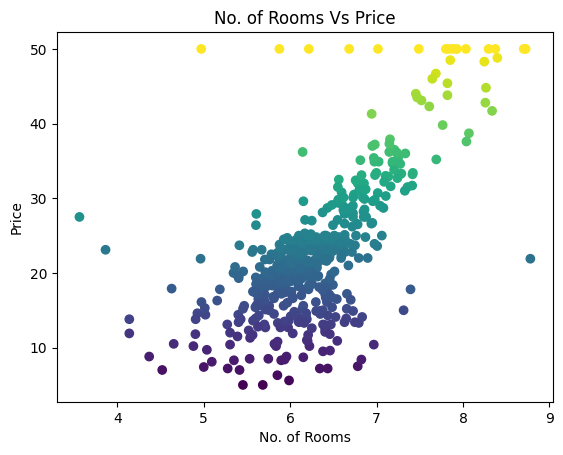

In [121]:
plt.title('No. of Rooms Vs Price')
plt.xlabel('No. of Rooms')
plt.ylabel('Price')
plt.scatter(x=df['rooms'], y=df['price'], c=df['price'])
plt.show()

In [122]:
df.head()

,crime,zone,industry,river,air pollution,rooms,age,distance,highway access,ptax,ptration,bindex,lstat,price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [123]:
X = df.drop(columns=['price'], axis=1)
y = df['price']

In [136]:
X

,crime,zone,industry,river,air pollution,rooms,age,distance,highway access,ptax,ptration,bindex,lstat
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
X_train.shape

(404, 13)

In [126]:
X_test.shape

(102, 13)

In [127]:
y_train.shape

(404,)

In [128]:
y_test.shape

(102,)

In [129]:
# Model objects
linear_reg = LinearRegression()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor()
bag = BaggingRegressor()

In [130]:
# Traning all the models
linear_reg.fit(X_train, y_train)
knn.fit(X_train, y_train)
dt.fit(X_train, y_train)
bag.fit(X_train, y_train)

BaggingRegressor()

In [131]:
# Prediction from all the models
y_pred_lr = linear_reg.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_bag = bag.predict(X_test)

In [135]:
# R2 score
print(f'Linear Regression: {r2_score(y_test, y_pred_lr):.2%}')
print(f'KNeighbors Regressor: {r2_score(y_test, y_pred_knn):.2%}')
print(f'Decision Tree Regressor: {r2_score(y_test, y_pred_dt):.2%}')
print(f'Bagging Regressor: {r2_score(y_test, y_pred_bag):.2%}')

Linear Regression: 66.88%
KNeighbors Regressor: 64.74%
Decision Tree Regressor: 74.41%
Bagging Regressor: 85.90%


In [133]:
print(f'Training R^2 Score: {bag.score(X_train, y_train):.2%}')
print(f'Testing R^2 Score:{bag.score(X_test, y_test):.2%}')

Training R^2 Score: 97.33%
Testing R^2 Score:85.90%


In [142]:
params = {
    'estimator': [LinearRegression(), KNeighborsRegressor()],
    'n_estimators': [10, 20, 50, 100, 300, 500],
    'max_samples': [0.25, 0.5, 1.0],
    'max_features': [0.25, 0.5, 1.0],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]
}

In [143]:
# Grid Search Setup
grid_search = GridSearchCV(
    estimator=BaggingRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit Grid Search
grid_search.fit(X_train, y_train)

# Output Results
print(f"Best Parameters:\n{grid_search.best_params_}")
print(f"Best R² from CV: {grid_search.best_score_:.2%}")
print(f"Train R² Score:  {grid_search.best_estimator_.score(X_train, y_train):.2%}")
print(f"Test R² Score:   {grid_search.best_estimator_.score(X_test, y_test):.2%}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters:
{'bootstrap': False, 'bootstrap_features': False, 'estimator': LinearRegression(), 'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 20}
Best R² from CV: 72.59%
Train R² Score:  75.06%
Test R² Score:   67.10%
